# 7일 무료 체험 행동 기반 최종 전환 분석 (Aha Moment 찾기)

이 노트북은 가입 후 초기 7일간의 유저 행동 데이터를 상세히 분석하여, 최종적으로 유료 결제에 이르는 핵심 행동(Aha Moment)을 탐색합니다.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import timedelta

# 시각화 한글 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

## TASK 1. 데이터 로드 및 전처리

In [40]:
df_funnel = pd.read_csv('data/funnel_join2.csv')
df_payment = pd.read_csv('data/payment_transactions.csv')

df_funnel['event_timestamp'] = pd.to_datetime(df_funnel['event_timestamp'], format='mixed', errors='coerce')
df_payment['transaction_date'] = pd.to_datetime(df_payment['transaction_date'], format='mixed', errors='coerce')

# 유효하지 않은 날짜(NaT) 제거
df_funnel = df_funnel.dropna(subset=['event_timestamp'])
df_payment = df_payment.dropna(subset=['transaction_date'])

print(f"이벤트 로그 수: {len(df_funnel)}")
print(f"결제 데이터 수: {len(df_payment)}")

이벤트 로그 수: 748964
결제 데이터 수: 8177


### 유저별 가입일(T0) 식별 및 초기 7일 행동 데이터 필터링

In [41]:
# 1. 각 유저별 가입 완료(signup_completed) 시점 찾기
df_signup = df_funnel[df_funnel['event_name'] == 'signup_completed'].sort_values('event_timestamp').groupby('user_id').first().reset_index()
df_signup = df_signup[['user_id', 'event_timestamp']].rename(columns={'event_timestamp': 'signup_time'})

# 2. 원본 데이터에 가입 시점 병합
df_merged = pd.merge(df_funnel, df_signup, on='user_id', how='inner')

# 3. 가입 시점으로부터 7일(168시간) 이내의 행동 이벤트만 필터링
df_7d_behavior = df_merged[(df_merged['event_timestamp'] >= df_merged['signup_time']) & 
                           (df_merged['event_timestamp'] <= df_merged['signup_time'] + timedelta(days=7))]

print(f"초기 7일 이내 행동 이벤트 수: {len(df_7d_behavior)}")
print(f"분석 대상 유저 수: {df_7d_behavior['user_id'].nunique()}")

초기 7일 이내 행동 이벤트 수: 277412
분석 대상 유저 수: 14050


### 최종 전환 유저 식별 (가입 후 모든 기간 적용)

In [42]:
# 1. 성공적인 결제 이력이 있는 모든 유저 추출
final_converted_users = df_payment[df_payment['status'] == 'completed']['user_id'].unique()

# 2. 분석 대상 유저 베이스 생성 (초기 7일 행동이 있는 유저 중 최종 결제 여부 확인)
user_base = df_7d_behavior[['user_id']].drop_duplicates()
user_base['converted'] = user_base['user_id'].isin(final_converted_users)

print(f"최종 전환 유저: {user_base['converted'].sum()}명")
print(f"전체 최종 전환율: {user_base['converted'].mean()*100:.2f}%")

최종 전환 유저: 3920명
전체 최종 전환율: 27.90%


### 가입 주차별 전환율 분석 (Task 1 추가)

유저가 가입한 주(Week) 단위로 전환율이 어떻게 변화하는지 분석합니다.

--- 주차별 전환율 현황 ---


,signup_week,total_users,converted_users,conversion_rate
0,2025-01-06,375,131,34.93
1,2025-01-13,389,142,36.50
2,2025-01-20,428,160,37.38
3,2025-01-27,470,150,31.91
4,2025-02-03,488,172,35.25
5,2025-02-10,546,190,34.80
6,2025-02-17,576,191,33.16
7,2025-02-24,648,208,32.10
8,2025-03-03,673,206,30.61
9,2025-03-10,657,211,32.12


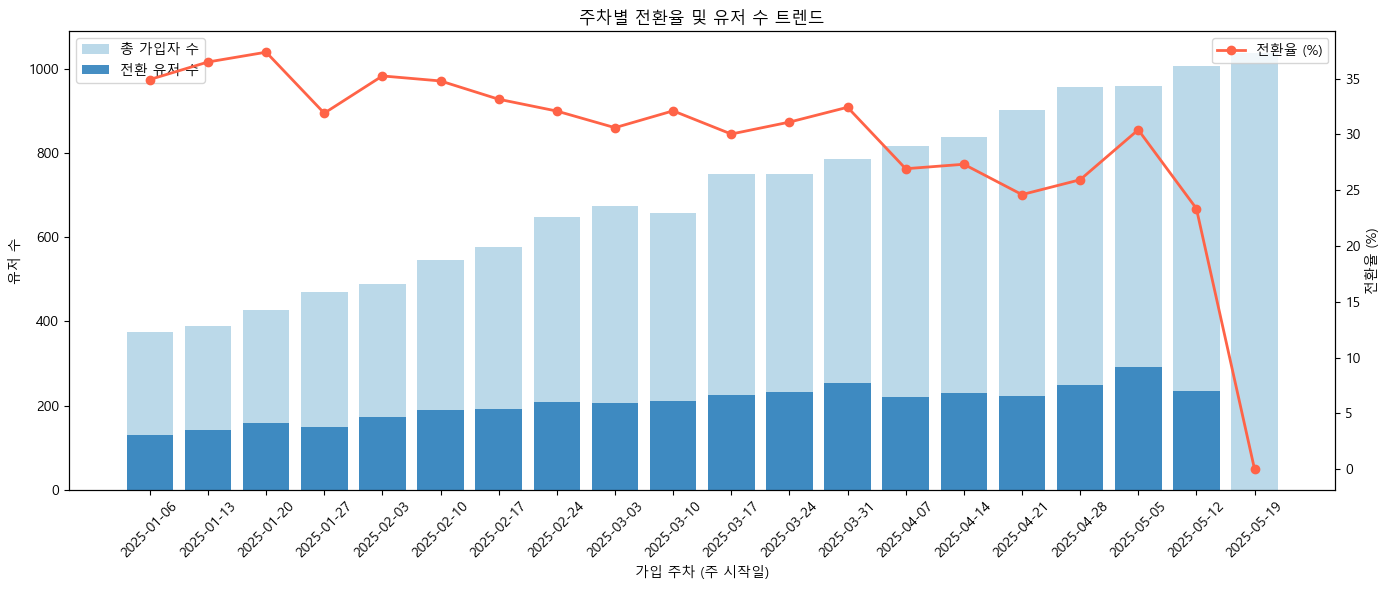

In [ ]:
# 주차별 전환율 분석

# 1. 가입 주차(Week) 생성
df_signup_weekly = df_signup.copy()
df_signup_weekly['signup_week'] = df_signup_weekly['signup_time'].dt.to_period('W').dt.start_time.dt.strftime('%Y-%m-%d')

# 2. user_behavior와 가입 주차 결합
weekly_analysis = pd.merge(
    user_behavior[['user_id', 'converted']],
    df_signup_weekly[['user_id', 'signup_week']],
    on='user_id',
    how='left'
)

# 3. 주차별 전환 현황 집계
weekly_summary = weekly_analysis.groupby('signup_week').agg(
    total_users=('user_id', 'count'),
    converted_users=('converted', 'sum')
).reset_index()
weekly_summary['conversion_rate'] = (weekly_summary['converted_users'] / weekly_summary['total_users']) * 100
weekly_summary['conversion_rate'] = weekly_summary['conversion_rate'].round(2)

print('--- 주차별 전환율 현황 ---')
display(weekly_summary)

# 4. 시각화 -- 이중 y축 사용 (라인: 전환율, 막대: 총 가입자)
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(weekly_summary['signup_week'], weekly_summary['total_users'], color='#9ecae1', alpha=0.7, label='총 가입자 수')
ax1.bar(weekly_summary['signup_week'], weekly_summary['converted_users'], color='#3182bd', alpha=0.9, label='전환 유저 수')
ax1.set_xlabel('가입 주차 (주 시작일)')
ax1.set_ylabel('유저 수')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(weekly_summary['signup_week'], weekly_summary['conversion_rate'], color='tomato', marker='o', linewidth=2, label='전환율 (%)')
ax2.set_ylabel('전환율 (%)')
ax2.legend(loc='upper right')

plt.title('주차별 전환율 및 유저 수 트렌드')
plt.tight_layout()
plt.show()

## Task 2. 상세 행동 지표 비교 (가입 초기 7일 기준)

In [44]:
# 3. 유저별 상세 행동 지표 집계 (가입 후 7일 이내)
import json

# 1) 단순 이벤트 횟수 집계
action_counts = df_7d_behavior.groupby(['user_id', 'event_name']).size().unstack(fill_value=0)

# 분석에 필요한 컬럼 보장
required_actions = ['course_detail_viewed', 'course_searched', 'lesson_started', 'lesson_completed', 'quiz_submitted']
for col in required_actions:
    if col not in action_counts.columns:
        action_counts[col] = 0

# 2) 수강 시간(분) 집계 (lesson_started의 duration_min 활용)
def extract_duration(prop_str):
    try:
        props = json.loads(prop_str)
        return props.get('duration_min', 0)
    except:
        return 0

study_time = df_7d_behavior[df_7d_behavior['event_name'] == 'lesson_started'].copy()
study_time['duration'] = study_time['event_properties'].apply(extract_duration)
user_study_min = study_time.groupby('user_id')['duration'].sum()

# 3) 퀴즈 정답 수 집계 (quiz_submitted의 is_correct 활용)
def extract_correct(prop_str):
    try:
        props = json.loads(prop_str)
        return 1 if props.get('is_correct') == True else 0
    except:
        return 0

quiz_info = df_7d_behavior[df_7d_behavior['event_name'] == 'quiz_submitted'].copy()
quiz_info['correct'] = quiz_info['event_properties'].apply(extract_correct)
user_quiz_correct = quiz_info.groupby('user_id')['correct'].sum()

# 4) 활성 일수 (active_days)
df_7d_behavior_copy = df_7d_behavior.copy()
df_7d_behavior_copy['event_date'] = pd.to_datetime(df_7d_behavior_copy['event_timestamp']).dt.date
user_active_days = df_7d_behavior_copy.groupby('user_id')['event_date'].nunique()

# 5) 온보딩 완료 여부 (onboarding_done)
user_onboarding = df_7d_behavior[df_7d_behavior['event_name'] == 'onboarding_completed']['user_id'].unique()

# 데이터 결합
user_behavior = user_base.copy()
user_behavior = user_behavior.set_index('user_id')

user_behavior['course_detail_viewed'] = action_counts['course_detail_viewed']
user_behavior['course_searched'] = action_counts['course_searched']
user_behavior['lesson_started'] = action_counts['lesson_started']
user_behavior['lesson_completed'] = action_counts['lesson_completed']
user_behavior['quiz_submitted'] = action_counts['quiz_submitted']
user_behavior['quiz_correct_count'] = user_quiz_correct
user_behavior['total_study_minutes'] = user_study_min
user_behavior['active_days'] = user_active_days
user_behavior['onboarding_done'] = user_behavior.index.isin(user_onboarding).astype(int)

# NaN 결측치 0으로 채우기 및 인덱스 리셋
user_behavior = user_behavior.fillna(0).reset_index()

print(f"행동 지표 집계 완료: {user_behavior.shape[0]}명")
user_behavior.head()


행동 지표 집계 완료: 14050명


,user_id,converted,course_detail_viewed,course_searched,lesson_started,lesson_completed,quiz_submitted,quiz_correct_count,total_study_minutes,active_days,onboarding_done
0,U-05023,True,0,0,0,0,0,0.0,0.0,1,0
1,U-05018,True,2,0,1,1,1,1.0,26.0,3,1
2,U-05031,False,1,1,0,0,0,0.0,0.0,3,0
3,U-05041,True,0,2,3,3,0,0.0,29.0,3,0
4,U-05032,False,1,0,1,0,0,0.0,12.0,3,1


In [44]:
# 그룹별 평균, 인원수 및 차이 분석
cols_to_compare = [
    'course_detail_viewed', 'course_searched', 'lesson_started', 'lesson_completed', 
    'quiz_submitted', 'quiz_correct_count', 
    'total_study_minutes', 'active_days', 'onboarding_done'
]

# 1. 그룹별 평균 및 인원수 계산
comparison = user_behavior.groupby('converted')[cols_to_compare].mean()
comparison['user_count'] = user_behavior.groupby('converted')['user_id'].count()

# 2. 인덱스를 문자열로 변환하여 KeyError 방지 및 행 추가 용이하게 설정
comparison.index = comparison.index.astype(str)

# 3. 차이(Diff) 및 증감률(%) 계산
if 'True' in comparison.index and 'False' in comparison.index:
    diff = comparison.loc['True'] - comparison.loc['False']
    # 0으로 나누는 경우 방지
    pct_change = (diff / comparison.loc['False'].replace(0, np.nan)) * 100
    
    # 4. 결과 테이블 구성
    result_df = comparison.copy()
    result_df.loc['Diff'] = diff
    result_df.loc['Diff (%)'] = pct_change
else:
    result_df = comparison # 데이터가 부족할 경우

print("--- 최종 전환 여부에 따른 초기 7일간의 평균 행동 지표 및 인원수/차이 분석 ---")
display(result_df.round(2))


--- 최종 전환 여부에 따른 초기 7일간의 평균 행동 지표 및 인원수/차이 분석 ---


,course_detail_viewed,course_searched,lesson_started,lesson_completed,quiz_submitted,quiz_correct_count,total_study_minutes,active_days,onboarding_done,user_count
converted,,,,,,,,,,
False,0.89,0.56,1.44,1.27,0.14,0.07,20.88,2.71,0.58,10130.0
True,1.04,0.67,1.94,1.74,0.27,0.19,28.63,3.05,0.64,3920.0
Diff,0.15,0.11,0.50,0.47,0.13,0.12,7.75,0.34,0.06,-6210.0
Diff (%),17.31,20.05,34.74,37.41,92.73,164.07,37.13,12.38,10.21,-61.3


### 횟수별 전환율 상세 분석 (Task 2-2)

1. 강의 상세 조회 수별 전환율


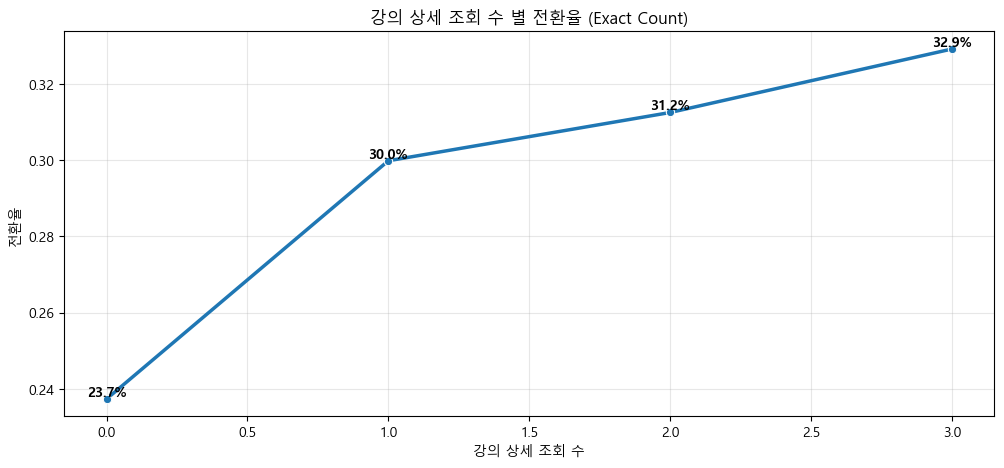

2. 레슨 완료 수별 전환율


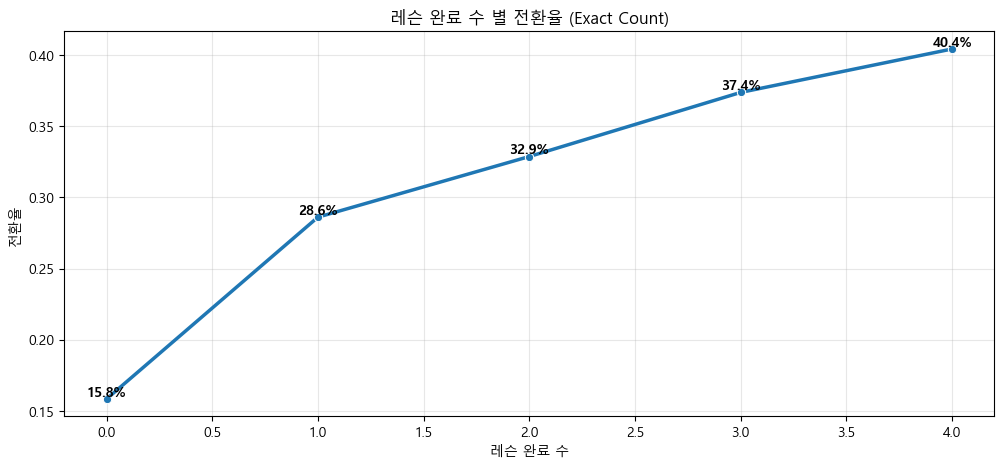

3. 활성 일수별 전환율


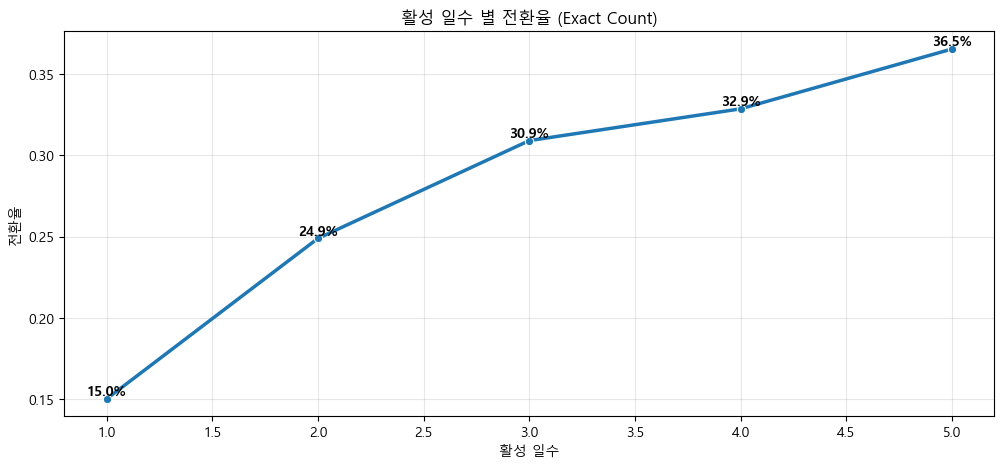

In [45]:
def plot_conversion_line_chart(df, column, title):
    # 횟수별 '딱 그 횟수만큼' 행동한 유저의 전환율 (꺽은선 그래프)
    max_val = int(df[column].quantile(0.95)) if df[column].nunique() > 1 else 1
    
    res = []
    for i in range(max_val + 1):
        subset = df[df[column] == i]
        if len(subset) > 0:
            cr = subset['converted'].mean()
            res.append({'횟수': i, '전환율': cr, '유저수': len(subset)})
    
    res_df = pd.DataFrame(res)
    
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=res_df, x='횟수', y='전환율', marker='o', linewidth=2.5, color='#1f77b4')
    plt.title(f'{title} 별 전환율 (Exact Count)')
    plt.ylabel('전환율')
    plt.xlabel(f'{title}')
    
    for idx, row in res_df.iterrows():
        plt.text(row['횟수'], row['전환율'], f"{row['전환율']*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    return res_df

print("1. 강의 상세 조회 수별 전환율")
detail_view_cr_table = plot_conversion_line_chart(user_behavior, 'course_detail_viewed', '강의 상세 조회 수')

print("2. 레슨 완료 수별 전환율")
lesson_cr_table = plot_conversion_line_chart(user_behavior, 'lesson_completed', '레슨 완료 수')

print("3. 활성 일수별 전환율")
active_cr_table = plot_conversion_line_chart(user_behavior, 'active_days', '활성 일수')

### Task 2-3. CS 상담(Chat) 데이터 및 만족도 분석
가입 후 초기 7일 이내에 CS 상담을 진행한 경험이 유료 전환에 어떤 영향을 미치는지 분석합니다.

In [ ]:
# 1. 데이터 로드 및 초기 7일 기준 필터링
df_chat = pd.read_csv('data/chat_events.csv')
df_chat['chat_date'] = pd.to_datetime(df_chat['chat_date'])

# 유저별 가입일 정보 결합 (signup_time 활용)
df_chat = df_chat.merge(df_signup[['user_id', 'signup_time']], on='user_id', how='inner')

# 가입 후 7일 이내 상담만 필터링
df_chat_7d = df_chat[df_chat['chat_date'] <= (df_chat['signup_time'] + pd.Timedelta(days=7))].copy()

# 상담 정보 집계 (유저별)
# 1) 상담 여부
chat_users = df_chat_7d['user_id'].unique()
user_behavior['chat_ever'] = user_behavior['user_id'].isin(chat_users).astype(int)

# 2) 상담 카테고리 (가장 많이 상담한 카테고리 하나만 선택)
user_chat_cat = df_chat_7d.groupby('user_id')['category'].agg(lambda x: x.value_counts().index[0])
user_behavior = user_behavior.merge(user_chat_cat.rename('chat_category'), on='user_id', how='left')

# 3) 평균 상담 만족도
user_chat_sat = df_chat_7d.groupby('user_id')['satisfaction_score'].mean()
user_behavior = user_behavior.merge(user_chat_sat.rename('chat_avg_satisfaction'), on='user_id', how='left')

print(f"7일 이내 상담 유저 수: {len(chat_users)}명")
user_behavior[['user_id', 'chat_ever', 'chat_category', 'chat_avg_satisfaction']].head()

7일 이내 상담 유저 수: 202명


,user_id,chat_ever,chat_category,chat_avg_satisfaction
0,U-05023,0,NaN,NaN
1,U-05018,0,NaN,NaN
2,U-05031,0,NaN,NaN
3,U-05041,0,NaN,NaN
4,U-05032,0,NaN,NaN


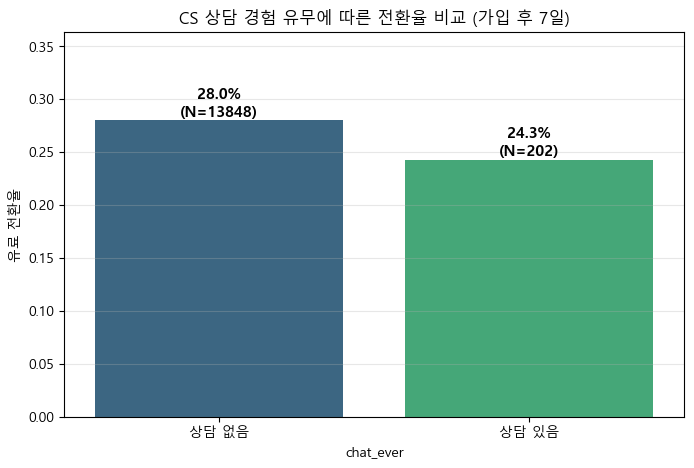

In [ ]:
# 2. 상담 여부에 따른 전환율 비교
chat_cr = user_behavior.groupby('chat_ever')['converted'].mean()
chat_count = user_behavior['chat_ever'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=chat_cr.index, y=chat_cr.values, palette='viridis')
plt.title('CS 상담 경험 유무에 따른 전환율 비교 (가입 후 7일)')
plt.xticks([0, 1], ['상담 없음', '상담 있음'])
plt.ylabel('유료 전환율')

for i, val in enumerate(chat_cr.values):
    plt.text(i, val, f'{val*100:.1f}%\n(N={chat_count[i]})', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(chat_cr.values) * 1.3)
plt.grid(axis='y', alpha=0.3)
plt.show()

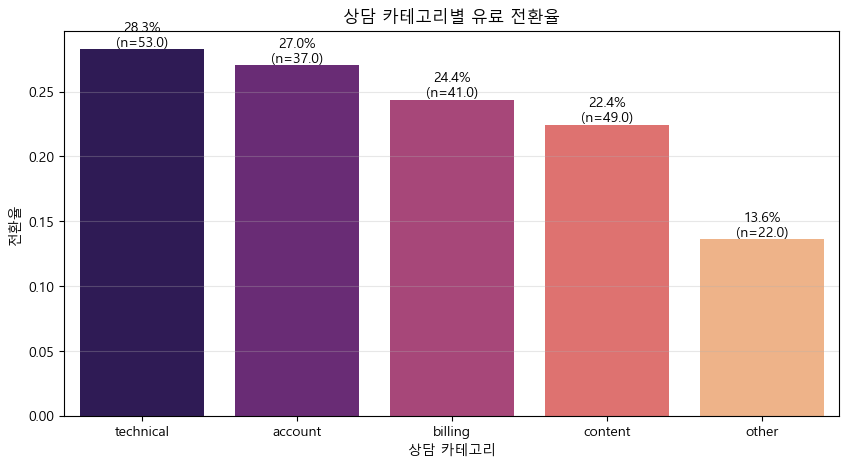

In [46]:
# 3. 상담 카테고리별 전환율 분석
cat_analysis = user_behavior[user_behavior['chat_ever'] == 1].groupby('chat_category')['converted'].agg(['mean', 'count'])
cat_analysis = cat_analysis.sort_values(by='mean', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_analysis.index, y=cat_analysis['mean'], palette='magma')
plt.title('상담 카테고리별 유료 전환율')
plt.ylabel('전환율')
plt.xlabel('상담 카테고리')

for i, val in enumerate(cat_analysis['mean']):
    plt.text(i, val, f'{val*100:.1f}%\n(n={cat_analysis.iloc[i]["count"]})', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.show()

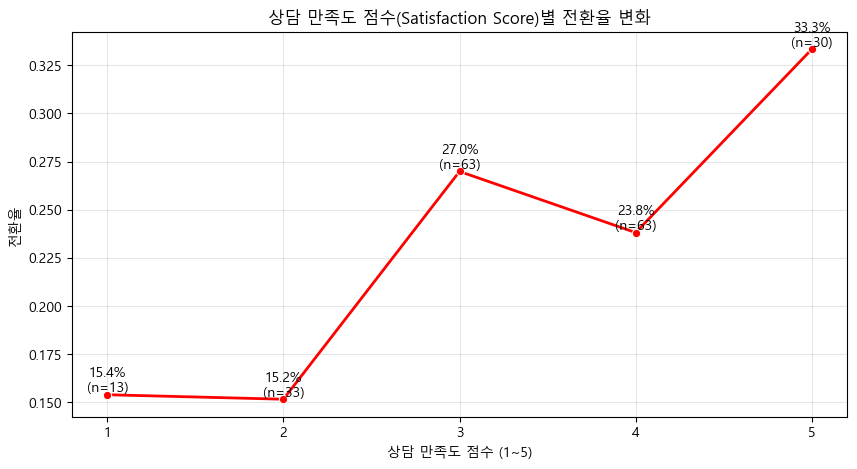

In [45]:
# 4. 상담 만족도 점수와 전환율의 상관관계
sat_analysis = user_behavior[user_behavior['chat_ever'] == 1].copy()
# 점수를 반올림하여 그룹화
sat_analysis['sat_score_int'] = sat_analysis['chat_avg_satisfaction'].round()

sat_cr = sat_analysis.groupby('sat_score_int')['converted'].agg(['mean', 'count'])

plt.figure(figsize=(10, 5))
sns.lineplot(x=sat_cr.index, y=sat_cr['mean'], marker='o', color='red', linewidth=2)
plt.title('상담 만족도 점수(Satisfaction Score)별 전환율 변화')
plt.xlabel('상담 만족도 점수 (1~5)')
plt.ylabel('전환율')

for x, y, n in zip(sat_cr.index, sat_cr['mean'], sat_cr['count']):
    plt.text(x, y, f'{y*100:.1f}%\n(n={int(n)})', ha='center', va='bottom', fontsize=10)

plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.show()

### Task 2-4. 전환 소요 기간별 행동 패턴 비교 (비전환자 포함 / 16일 기준)

유저를 전환 속도 및 여부에 따라 세 그룹으로 나눕니다.
- **빠른 전환 (Early)**: 가입 후 16일 이내 결제 완료
- **느린 전환 (Late)**: 가입 후 16일 초과 결제 완료
- **비전환 (Non-Converted)**: 결제 이력이 없는 유저

이 세 그룹의 가입 초기 7일간의 행동 지표 평균과 인원수를 비교합니다.

In [48]:
# 1. 유저별 첫 결제 시점 기반 그룹화
df_first_payment = df_payment[df_payment['status'] == 'completed'].sort_values('transaction_date').groupby('user_id').first().reset_index()
df_first_payment = df_first_payment[['user_id', 'transaction_date']].rename(columns={'transaction_date': 'first_payment_time'})

# 2. 가입 시점과 결합하여 소요 기간 계산
df_conv_speed = pd.merge(df_signup, df_first_payment, on='user_id', how='left')
df_conv_speed['days_to_convert'] = (df_conv_speed['first_payment_time'] - df_conv_speed['signup_time']).dt.total_seconds() / (24 * 3600)

# 3. 그룹화 (Early, Late, Non-Converted)
def categorize_v2(row):
    if pd.isna(row['first_payment_time']):
        return '3. Non-Converted'
    elif row['days_to_convert'] <= 16:
        return '1. Early (<=16d)'
    else:
        return '2. Late (>16d)'

df_conv_speed['conv_group'] = df_conv_speed.apply(categorize_v2, axis=1)

print("--- 그룹별 유저 분포 ---")
df_conv_speed['conv_group'].value_counts().sort_index()

--- 그룹별 유저 분포 ---


conv_group
1. Early (<=16d)     3206
2. Late (>16d)        714
3. Non-Converted    10130
Name: count, dtype: int64

--- 전환 속도 및 여부에 따른 초기 7일 행동 지표 평균 비교 ---


,course_detail_viewed,course_searched,lesson_started,lesson_completed,quiz_submitted,quiz_correct_count,total_study_minutes,active_days,onboarding_done,user_count
conv_group,,,,,,,,,,
1. Early (<=16d),1.10,0.70,2.11,1.91,0.31,0.22,31.21,3.13,0.66,3206
2. Late (>16d),0.79,0.55,1.17,1.02,0.11,0.06,17.06,2.70,0.54,714
3. Non-Converted,0.89,0.56,1.44,1.27,0.14,0.07,20.88,2.71,0.58,10130


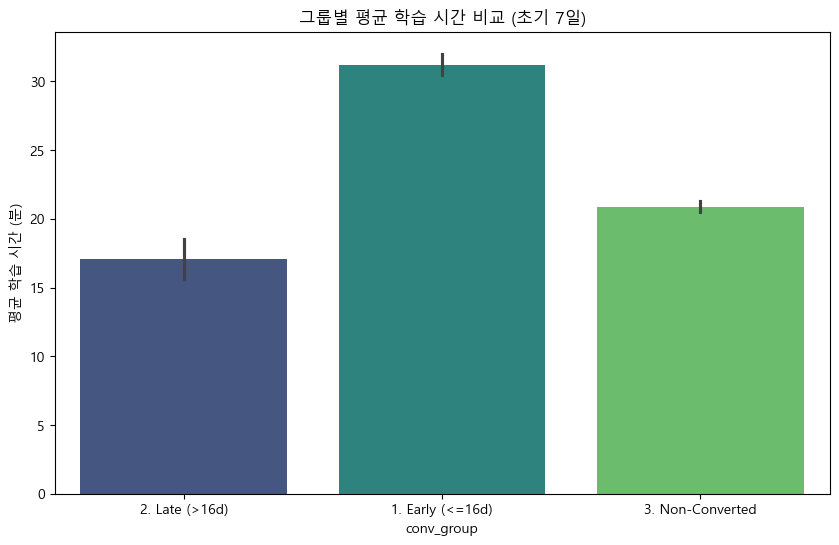

In [45]:
# 4. 그룹 정보를 user_behavior에 결합
user_behavior_all_groups = pd.merge(
    user_behavior.drop(columns=['converted']), # 기존 converted 컬럼 대신 상세 그룹 사용
    df_conv_speed[['user_id', 'conv_group']], 
    on='user_id', 
    how='inner'
)

cols_to_compare = [
    'course_detail_viewed', 'course_searched', 'lesson_started', 'lesson_completed', 
    'quiz_submitted', 'quiz_correct_count', 
    'total_study_minutes', 'active_days', 'onboarding_done'
]

# 5. 그룹별 평균 계산
speed_comparison_v2 = user_behavior_all_groups.groupby('conv_group')[cols_to_compare].mean()

# 6. 인원수(user_count) 추가
speed_comparison_v2['user_count'] = user_behavior_all_groups.groupby('conv_group')['user_id'].count()

print("--- 전환 속도 및 여부에 따른 초기 7일 행동 지표 평균 비교 ---")
display(speed_comparison_v2.round(2))

# 시각화 (인원수 차이가 크므로 평균값 위주 비중 확인)
plt.figure(figsize=(10, 6))
sns.barplot(data=user_behavior_all_groups, x='conv_group', y='total_study_minutes', palette='viridis')
plt.title('그룹별 평균 학습 시간 비교 (초기 7일)')
plt.ylabel('평균 학습 시간 (분)')
plt.show()


## Task 3. Aha Moment 탐색 (누적 기준)

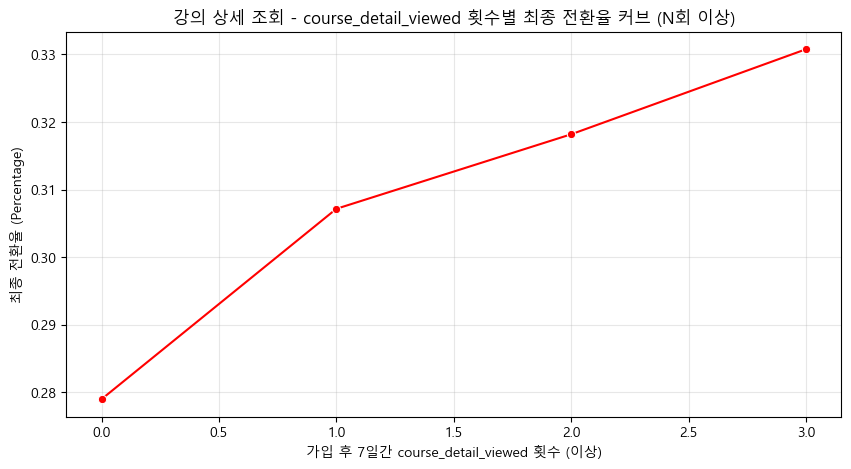

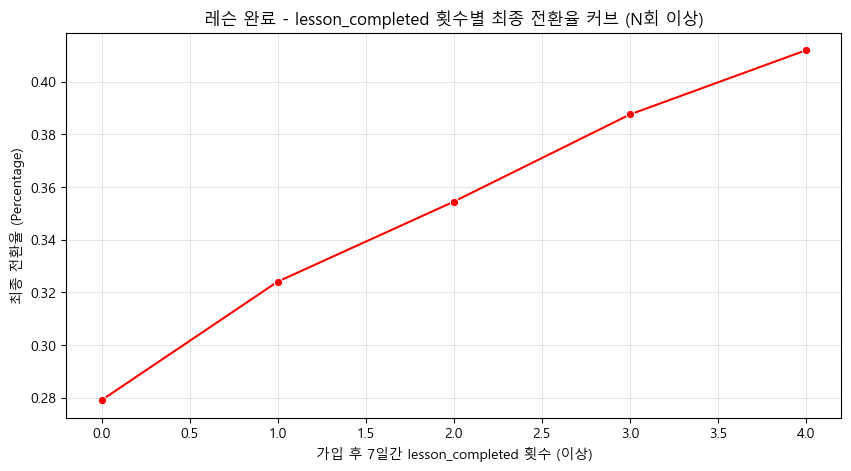

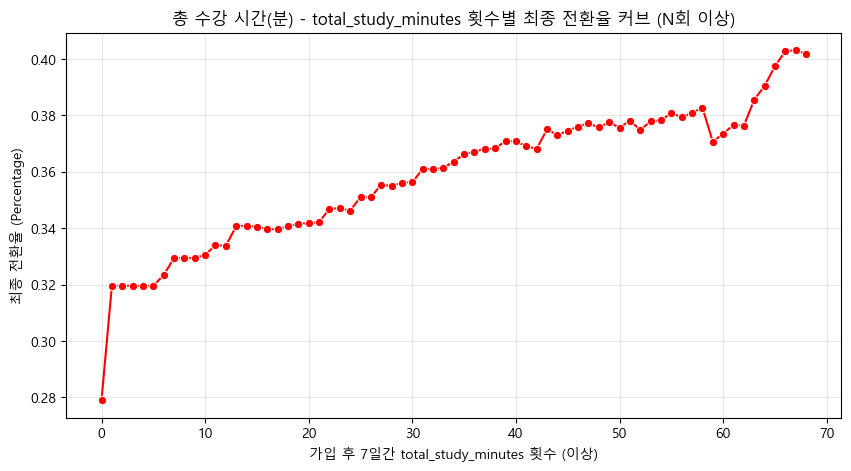

In [ ]:
def plot_conversion_curve_cumulative(df, column, title):
    # 특정 횟수 이상의 전환율 계산
    max_val = int(df[column].quantile(0.95)) if df[column].nunique() > 1 else 1
    
    res = []
    for i in range(max_val + 1):
        subset = df[df[column] >= i]
        if len(subset) > 0:
            cr = subset['converted'].mean()
            res.append({'count': i, 'cr': cr, 'user_count': len(subset)})
    
    res_df = pd.DataFrame(res)
    if res_df.empty: return res_df
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=res_df, x='count', y='cr', marker='o', color='red')
    plt.title(f'{title} - {column} 횟수별 최종 전환율 커브 (N회 이상)')
    plt.ylabel('최종 전환율 (Percentage)')
    plt.xlabel(f'가입 후 7일간 {column} 횟수 (이상)')
    plt.grid(True, alpha=0.3)
    plt.show()
    return res_df

detail_view_cr = plot_conversion_curve_cumulative(user_behavior, 'course_detail_viewed', '강의 상세 조회')
lesson_cr = plot_conversion_curve_cumulative(user_behavior, 'lesson_completed', '레슨 완료')
study_cr = plot_conversion_curve_cumulative(user_behavior, 'total_study_minutes', '총 수강 시간(분)')

## Task 4. 이탈 시점 분포(Day) 및 다각도 세그먼트 도달률 분석

비전환 유저의 이탈 전 마지막 5개 이벤트 패턴과 가입 후 경과 일수(Day)별 이탈 분포를 분석하고, 다양한 속성별 도달률을 비교합니다.

--- 비전환 유저의 이탈 전 마지막 5개 주요 이벤트 분포 ---


event_name
session_ended                12550
page_viewed                   9324
session_started               4777
lesson_completed              4393
lesson_started                3983
pricing_page_viewed           3321
course_detail_viewed          3087
course_searched               1833
onboarding_step_completed     1684
plan_selected                 1671
Name: count, dtype: int64

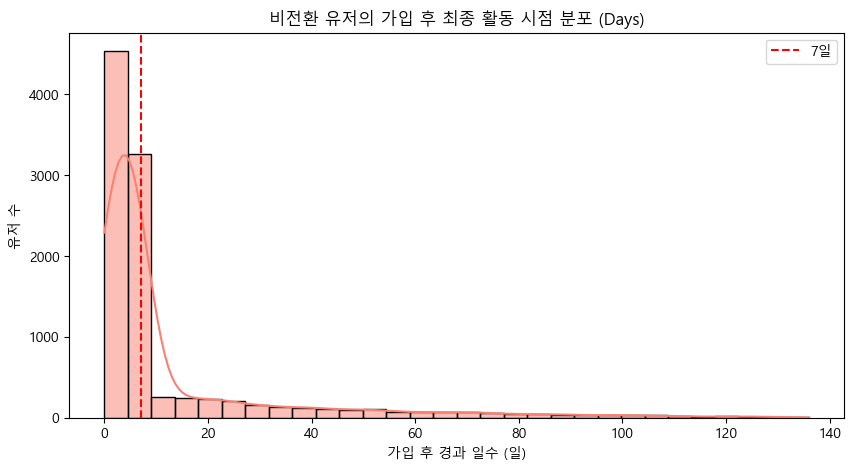

In [ ]:
# 1. 비전환 유저들의 마지막 5개 활동 단계 분석
non_converted_ids = user_behavior[user_behavior['converted'] == False]['user_id']
df_non_conv_behavior = df_merged[df_merged['user_id'].isin(non_converted_ids)]

# 유저별 마지막 5개 이벤트 추출
df_top5_events = df_non_conv_behavior.sort_values(['user_id', 'event_timestamp']).groupby('user_id').tail(5)

print("--- 비전환 유저의 이탈 전 마지막 5개 주요 이벤트 분포 ---")
top5_event_counts = df_top5_events['event_name'].value_counts()
display(top5_event_counts.head(10))

# 2. 이탈 시점(Day) 분포 계산
df_churn_point = df_non_conv_behavior.sort_values(['user_id', 'event_timestamp']).groupby('user_id').last().reset_index()
df_churn_point['days_since_signup'] = (df_churn_point['event_timestamp'] - df_churn_point['signup_time']).dt.total_seconds() / (3600 * 24)

# 3. 시각화: 이탈 시점(Day) 분포
plt.figure(figsize=(10, 5))
sns.histplot(df_churn_point['days_since_signup'], bins=30, kde=True, color='salmon')
plt.title('비전환 유저의 가입 후 최종 활동 시점 분포 (Days)')
plt.xlabel('가입 후 경과 일수 (일)')
plt.ylabel('유저 수')
plt.axvline(7, color='red', linestyle='--', label='7일')
plt.legend()
plt.show()


--- acquisition_source별 퍼널 단계 도달률 (%) ---


,session_started,signup_completed,course_detail_viewed,lesson_started,lesson_completed,pricing_page_viewed,plan_selected,checkout_started,subscribe,converted
acquisition_source,,,,,,,,,,
content_marketing,89.84,89.84,65.98,75.28,71.96,55.06,35.55,17.48,32.09,21.98
google_ads,89.90,89.90,68.36,73.26,69.78,49.95,30.82,20.15,40.29,30.25
instagram_influencer,89.14,89.14,62.74,69.67,63.16,50.46,30.16,14.12,31.08,20.22
meta_ads,91.58,91.58,56.59,58.79,48.64,33.21,18.41,6.96,27.09,18.72
organic,89.59,89.59,65.11,77.50,75.72,57.32,37.83,16.68,33.49,23.12
referral,89.42,89.42,71.28,79.47,78.12,62.53,42.32,28.00,41.05,30.47
youtube,88.87,88.87,68.61,76.56,75.10,57.22,37.14,21.48,38.78,27.65


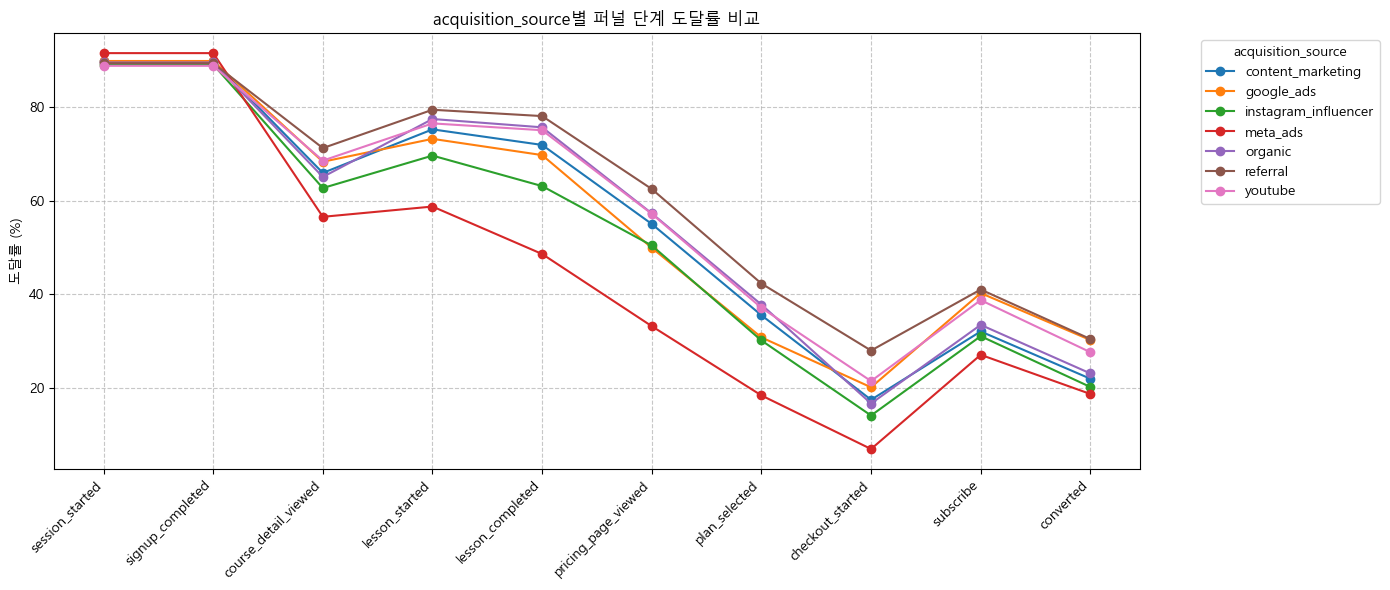


--- age_group별 퍼널 단계 도달률 (%) ---


,session_started,signup_completed,course_detail_viewed,lesson_started,lesson_completed,pricing_page_viewed,plan_selected,checkout_started,subscribe,converted
age_group,,,,,,,,,,
20-24,89.67,89.67,65.70,73.36,70.14,52.86,33.17,17.36,34.09,23.80
25-29,89.61,89.61,65.91,73.17,69.54,52.35,33.80,18.13,35.46,25.07
30-34,89.82,89.82,65.78,73.88,69.84,53.23,33.18,18.15,35.42,25.26
35-39,89.23,89.23,65.08,73.23,70.06,51.99,32.82,17.29,35.74,25.05
40+,91.47,91.47,66.97,73.50,69.60,49.73,33.58,17.97,35.12,26.68


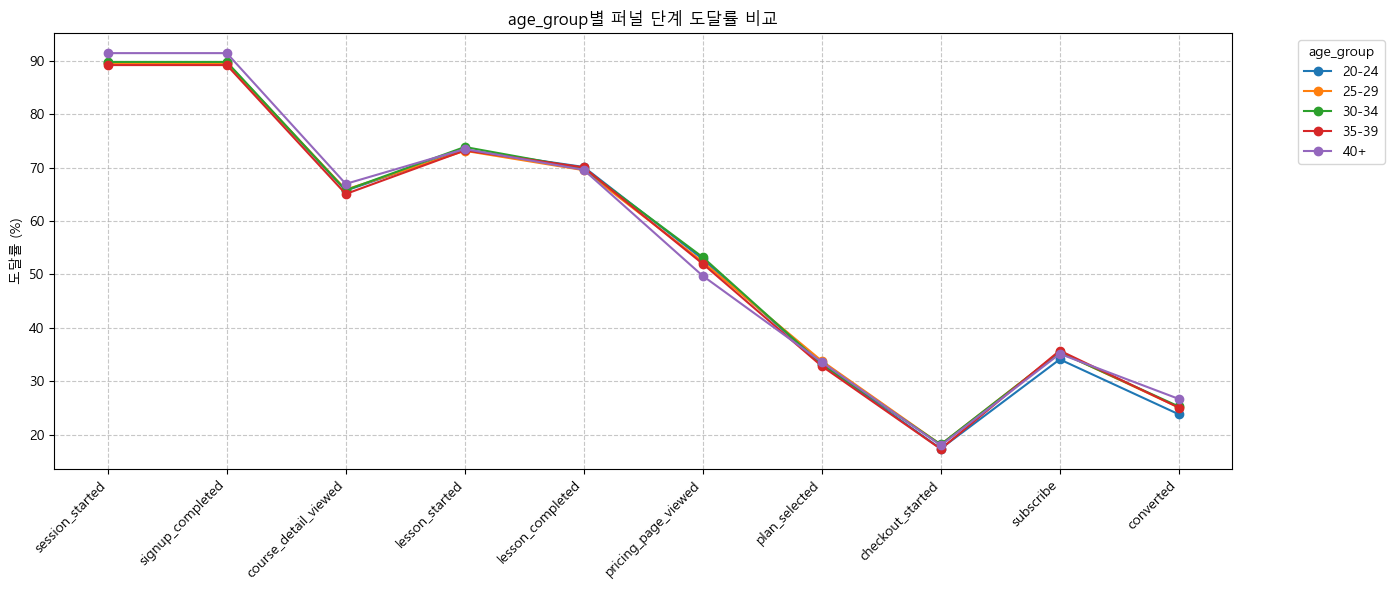


--- job_category별 퍼널 단계 도달률 (%) ---


,session_started,signup_completed,course_detail_viewed,lesson_started,lesson_completed,pricing_page_viewed,plan_selected,checkout_started,subscribe,converted
job_category,,,,,,,,,,
design,89.53,89.53,66.08,73.81,69.57,52.23,33.66,17.82,36.34,25.87
developer,88.69,88.69,63.47,72.03,68.74,52.47,32.52,17.91,34.41,23.17
finance,90.38,90.38,66.80,73.86,69.98,52.60,33.75,18.23,34.60,24.98
hr,89.51,89.51,67.04,73.83,69.63,50.74,31.73,15.68,37.65,27.28
marketing,89.92,89.92,66.09,72.86,69.80,51.44,32.29,18.03,35.31,25.31
office_admin,89.96,89.96,65.19,74.37,70.75,54.94,35.51,18.51,35.78,25.74
other,89.54,89.54,64.63,72.50,68.80,51.02,30.83,16.02,34.54,24.07
sales,89.79,89.79,66.46,73.01,69.10,53.15,34.62,18.73,33.61,23.39
student,89.91,89.91,65.98,73.99,70.47,52.47,33.73,18.03,35.33,25.27


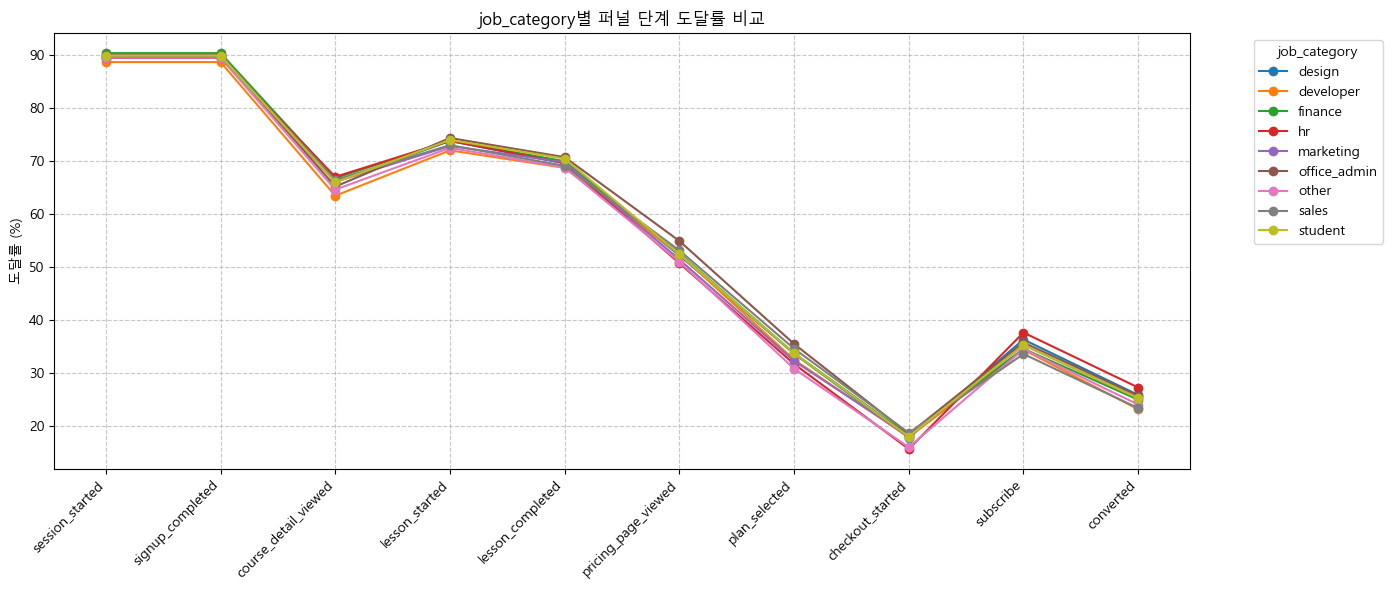

In [ ]:
# 4. 세그먼트별 퍼널 도달률 분석 (올바른 퍼널 순서 기반)
df_users = pd.read_csv('data/users.csv')
df_funnel_all = pd.read_csv('data/funnel_join2.csv')
df_funnel_all['event_timestamp'] = pd.to_datetime(df_funnel_all['event_timestamp'], format='mixed', errors='coerce')

# 퍼널 단계 정의 (비즈니스 순서대로)
funnel_steps = [
    'session_started',
    'signup_completed',
    'course_detail_viewed',
    'lesson_started',
    'lesson_completed',
    'pricing_page_viewed',
    'plan_selected',
    'checkout_started',
    'subscribe',
    'converted'
]

# 유저별 각 퍼널 단계 도달 여부 계산 (이벤트 기반 단계)
event_steps = [s for s in funnel_steps if s != 'converted']
user_funnel = df_funnel_all.groupby('user_id')['event_name'].apply(set).reset_index()
user_funnel.columns = ['user_id', 'event_set']

for step in event_steps:
    user_funnel[step] = user_funnel['event_set'].apply(lambda x: int(step in x))

# users.csv와 병합하여 세그먼트 정보 추가
user_funnel_seg = pd.merge(
    user_funnel[['user_id'] + event_steps],
    df_users[['user_id', 'acquisition_source', 'age_group', 'job_category']],
    on='user_id',
    how='inner'
)

# converted 컬럼 추가 (user_behavior 기준)
user_funnel_seg = pd.merge(
    user_funnel_seg,
    user_behavior[['user_id', 'converted']],
    on='user_id',
    how='left'
)
user_funnel_seg['converted'] = user_funnel_seg['converted'].fillna(False).astype(int)

# 세그먼트별 도달률 계산 및 시각화
segments_to_analyze = ['acquisition_source', 'age_group', 'job_category']

for segment_col in segments_to_analyze:
    if segment_col not in user_funnel_seg.columns:
        print(f"[경고] '{segment_col}' 컬럼이 없습니다. 건너뜁니다.")
        continue

    reach_rates = user_funnel_seg.groupby(segment_col)[funnel_steps].mean() * 100
    print(f"\n--- {segment_col}별 퍼널 단계 도달률 (%) ---")
    display(reach_rates.round(2))

    plt.figure(figsize=(14, 6))
    for seg_val in reach_rates.index:
        plt.plot(range(len(funnel_steps)), reach_rates.loc[seg_val], marker='o', label=str(seg_val))

    plt.title(f'{segment_col}별 퍼널 단계 도달률 비교')
    plt.ylabel('도달률 (%)')
    plt.xticks(range(len(funnel_steps)), funnel_steps, rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title=segment_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


### Task 4-추가. 행동 기반 퍼널 분석 (signup → lesson → quiz → converted)

핵심 학습 행동(레슨 학습, 퀴즈 응시)과 최종 전환 간의 퍼널을 분석합니다.

--- 행동 기반 퍼널 분석 결과 ---


,단계,유저 수,전체 대비 도달률(%),이전 단계 대비 이탈률(%)
0,signup_completed,14050,100.00,-
1,lesson_started,11495,81.81,18.19
2,lesson_completed,10926,77.77,4.95
3,quiz_submitted,4201,29.90,61.55
4,converted,3920,27.90,6.69


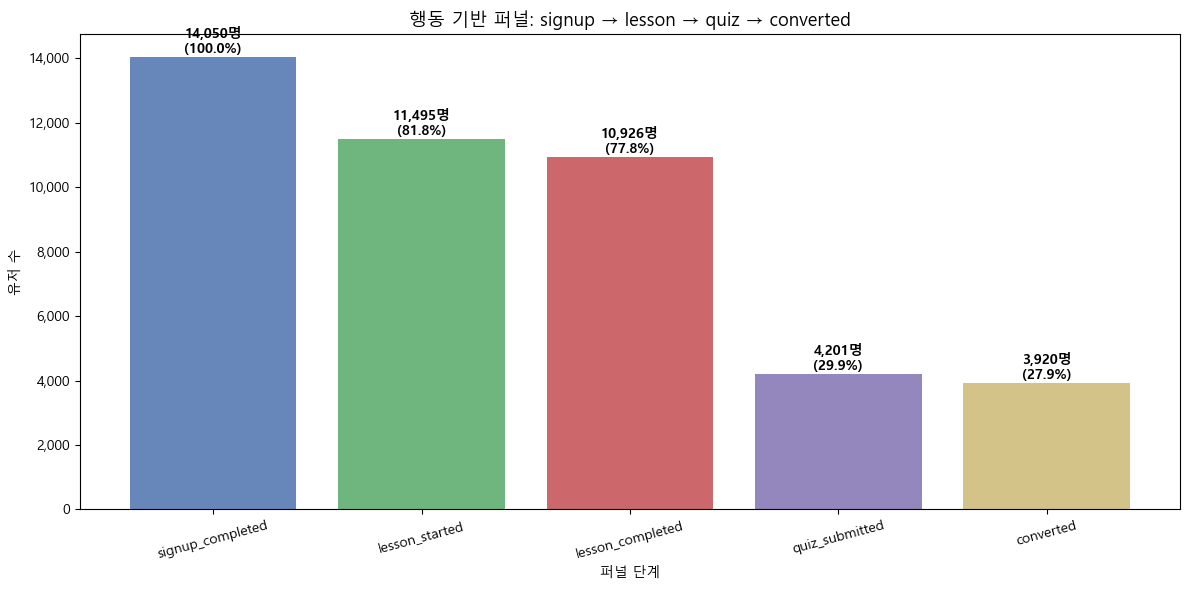

In [ ]:
# 행동 기반 퍼널 분석: signup_completed -> lesson_started -> lesson_completed -> quiz_submitted -> converted
import matplotlib.ticker as mticker

# 퍼널 단계 정의
action_funnel_steps = [
    'signup_completed',
    'lesson_started',
    'lesson_completed',
    'quiz_submitted',
]

# 전체 분석 대상 유저 (7일 이내 행동 데이터 기준)
df_funnel_base = df_merged.copy()

# 유저별 각 이벤트 도달 여부 계산
user_action_funnel = df_funnel_base.groupby('user_id')['event_name'].apply(set).reset_index()
user_action_funnel.columns = ['user_id', 'event_set']

for step in action_funnel_steps:
    user_action_funnel[step] = user_action_funnel['event_set'].apply(lambda x: int(step in x))

# converted 컬럼 추가 (payment_transactions 기준)
user_action_funnel = pd.merge(
    user_action_funnel[['user_id'] + action_funnel_steps],
    user_behavior[['user_id', 'converted']],
    on='user_id',
    how='left'
)
user_action_funnel['converted'] = user_action_funnel['converted'].fillna(False).astype(int)

# 전체 퍼널 단계
all_funnel_steps = action_funnel_steps + ['converted']

# 퍼널별 유저 수 및 도달률 계산
base_n = len(user_action_funnel)
funnel_counts = {step: user_action_funnel[step].sum() for step in all_funnel_steps}
funnel_rates = {step: v / base_n * 100 for step, v in funnel_counts.items()}
funnel_drop = {}
steps = list(funnel_counts.keys())
for i in range(1, len(steps)):
    prev = funnel_counts[steps[i-1]]
    curr = funnel_counts[steps[i]]
    funnel_drop[steps[i]] = (prev - curr) / prev * 100 if prev > 0 else 0

# 결과 테이블 출력
funnel_df = pd.DataFrame({
    '단계': all_funnel_steps,
    '유저 수': [funnel_counts[s] for s in all_funnel_steps],
    '전체 대비 도달률(%)': [round(funnel_rates[s], 2) for s in all_funnel_steps],
    '이전 단계 대비 이탈률(%)': ['-'] + [round(funnel_drop[s], 2) for s in all_funnel_steps[1:]]
})
print('--- 행동 기반 퍼널 분석 결과 ---')
display(funnel_df)

# 시각화: 퍼널 바 차트
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    all_funnel_steps,
    [funnel_counts[s] for s in all_funnel_steps],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'],
    alpha=0.85
)
for bar, step in zip(bars, all_funnel_steps):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 30,
            f'{int(h):,}명\n({funnel_rates[step]:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('행동 기반 퍼널: signup → lesson → quiz → converted', fontsize=13)
ax.set_ylabel('유저 수')
ax.set_xlabel('퍼널 단계')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 세그먼트별 퍼널 도달률 분석 (행동 기반 퍼널 기준)

signup → lesson_started → lesson_completed → quiz_submitted → converted 퍼널을 기반으로
유입 경로, 연령대, 직무별 단계별 도달률을 비교합니다.


--- acquisition_source별 퍼널 도달률 (%) ---


,signup_completed,lesson_started,lesson_completed,quiz_submitted,converted
acquisition_source,,,,,
content_marketing,100.0,83.79,80.09,28.06,24.46
google_ads,100.0,81.49,77.63,22.76,33.65
instagram_influencer,100.0,78.16,70.85,20.15,22.68
meta_ads,100.0,64.19,53.11,9.42,20.45
organic,100.0,86.50,84.52,40.24,25.80
referral,100.0,88.88,87.37,48.04,34.07
youtube,100.0,86.15,84.50,38.42,31.11


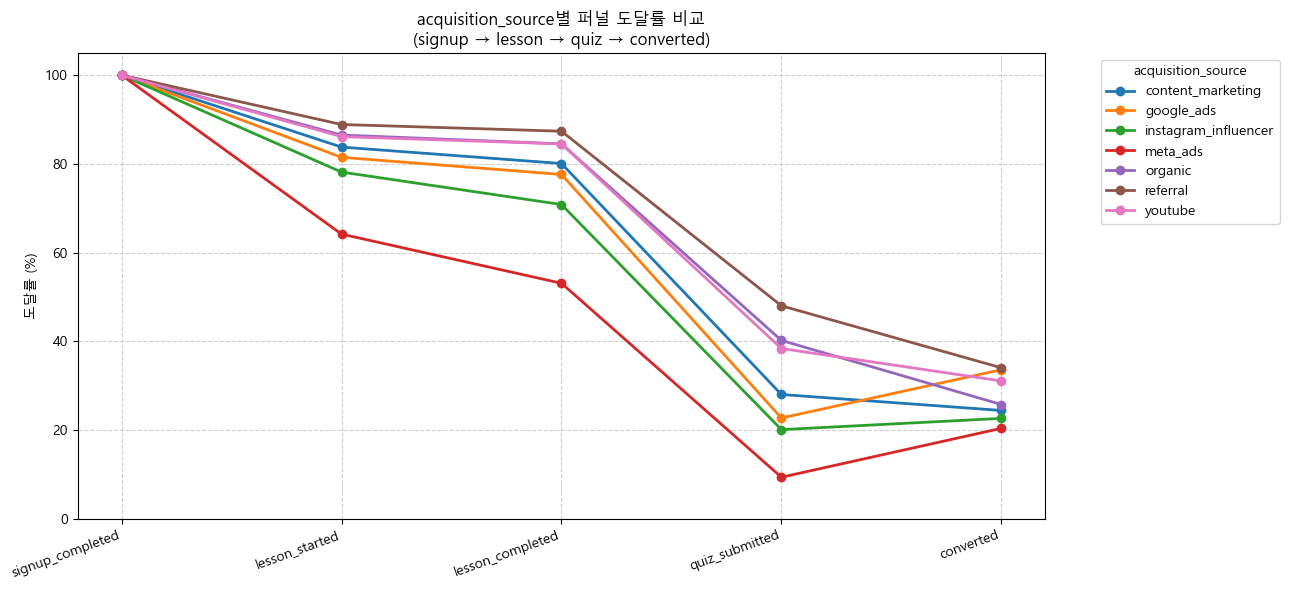


--- age_group별 퍼널 도달률 (%) ---


,signup_completed,lesson_started,lesson_completed,quiz_submitted,converted
age_group,,,,,
20-24,100.0,81.81,78.22,28.40,26.54
25-29,100.0,81.65,77.60,29.76,27.98
30-34,100.0,82.26,77.76,30.13,28.12
35-39,100.0,82.07,78.51,30.91,28.08
40+,100.0,80.36,76.09,30.75,29.17


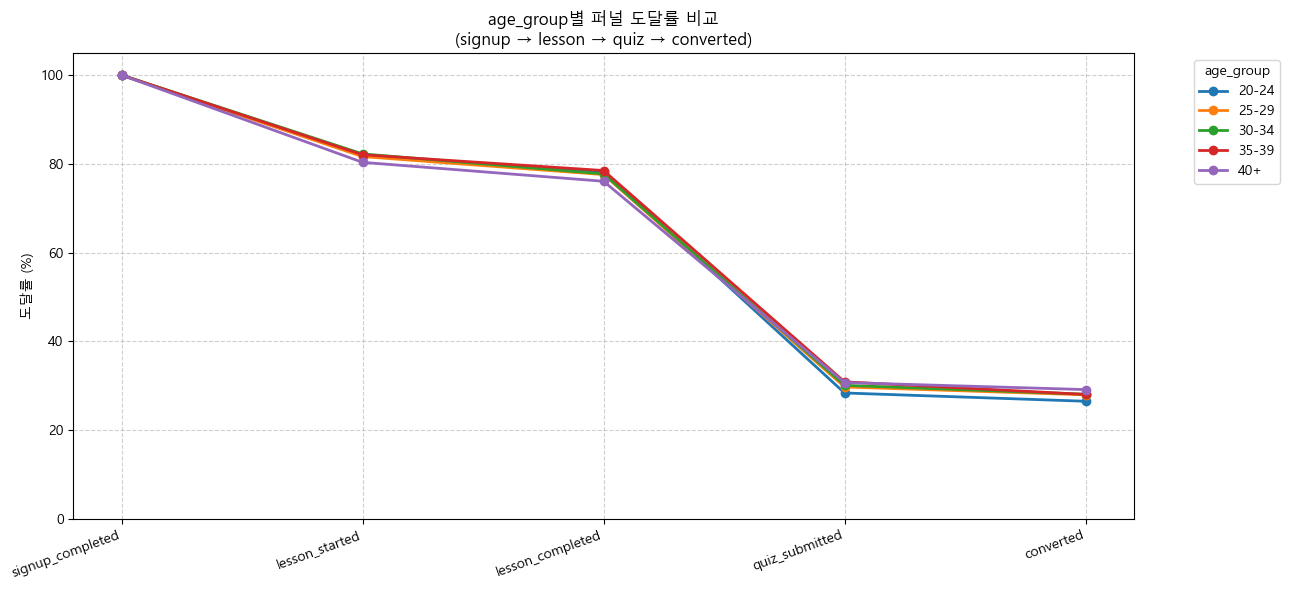


--- job_category별 퍼널 도달률 (%) ---


,signup_completed,lesson_started,lesson_completed,quiz_submitted,converted
job_category,,,,,
design,100.0,82.43,77.70,30.64,28.90
developer,100.0,81.22,77.50,27.37,26.13
finance,100.0,81.72,77.42,29.61,27.64
hr,100.0,82.48,77.79,32.41,30.48
marketing,100.0,81.02,77.62,29.58,28.14
office_admin,100.0,82.66,78.64,29.99,28.61
other,100.0,80.97,76.84,28.02,26.89
sales,100.0,81.32,76.97,30.06,26.05
student,100.0,82.29,78.38,30.74,28.11


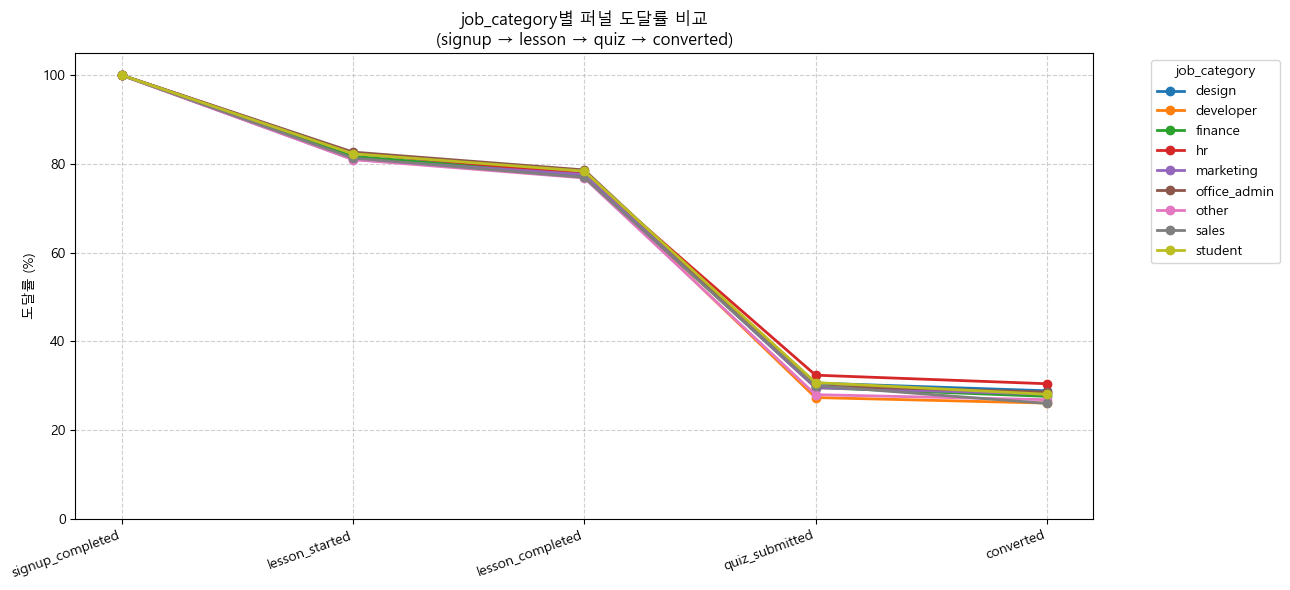

In [ ]:
# 행동 기반 퍼널 + 세그먼트별 도달률 분석
df_users = pd.read_csv('data/users.csv')

# 퍼널 단계 정의
action_funnel_steps = [
    'signup_completed',
    'lesson_started',
    'lesson_completed',
    'quiz_submitted',
]
all_funnel_steps = action_funnel_steps + ['converted']

# 유저별 각 이벤트 도달 여부 계산
user_seg_funnel = df_merged.groupby('user_id')['event_name'].apply(set).reset_index()
user_seg_funnel.columns = ['user_id', 'event_set']

for step in action_funnel_steps:
    user_seg_funnel[step] = user_seg_funnel['event_set'].apply(lambda x: int(step in x))

# converted 추가 (payment_transactions 기준)
user_seg_funnel = pd.merge(
    user_seg_funnel[['user_id'] + action_funnel_steps],
    user_behavior[['user_id', 'converted']],
    on='user_id',
    how='left'
)
user_seg_funnel['converted'] = user_seg_funnel['converted'].fillna(False).astype(int)

# 세그먼트 정보 병합
user_seg_funnel = pd.merge(
    user_seg_funnel,
    df_users[['user_id', 'acquisition_source', 'age_group', 'job_category']],
    on='user_id',
    how='left'
)

# 분석할 세그먼트 목록
segments_to_analyze = ['acquisition_source', 'age_group', 'job_category']

for segment_col in segments_to_analyze:
    if segment_col not in user_seg_funnel.columns:
        print(f'[경고] {segment_col} 컬럼 없음. 건너뜁니다.')
        continue

    reach_rates = user_seg_funnel.groupby(segment_col)[all_funnel_steps].mean() * 100
    print(f'\n--- {segment_col}별 퍼널 도달률 (%) ---')
    display(reach_rates.round(2))

    plt.figure(figsize=(13, 6))
    for seg_val in reach_rates.index:
        plt.plot(range(len(all_funnel_steps)), reach_rates.loc[seg_val],
                 marker='o', linewidth=2, label=str(seg_val))

    plt.title(f'{segment_col}별 퍼널 도달률 비교\n(signup → lesson → quiz → converted)')
    plt.ylabel('도달률 (%)')
    plt.xticks(range(len(all_funnel_steps)), all_funnel_steps, rotation=20, ha='right')
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title=segment_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


### 세그먼트 혼합 퍼널 도달률 분석 (상위 연령대 3 x 직무군 3)

유저 수가 가장 많은 연령대 3개, 직무군 3개를 선별하여 조합(age_group x job_category)별 퍼널 도달률을 비교합니다.

상위 3 연령대: ['25-29', '30-34']
상위 3 직무군: ['student', 'marketing']

필터링 후 유저 수: 3,346명
조합별 유저 수:


,유저 수
segment,
25-29 / student,962
25-29 / marketing,895
30-34 / student,818
30-34 / marketing,671



--- 연령대 x 직무군 조합별 퍼널 도달률 (%) ---


,signup_completed,lesson_started,lesson_completed,quiz_submitted,converted
segment,,,,,
25-29 / marketing,100.0,81.56,77.99,29.05,29.27
25-29 / student,100.0,82.74,80.15,31.60,29.11
30-34 / marketing,100.0,80.63,76.90,29.96,27.87
30-34 / student,100.0,81.66,76.89,32.03,27.14


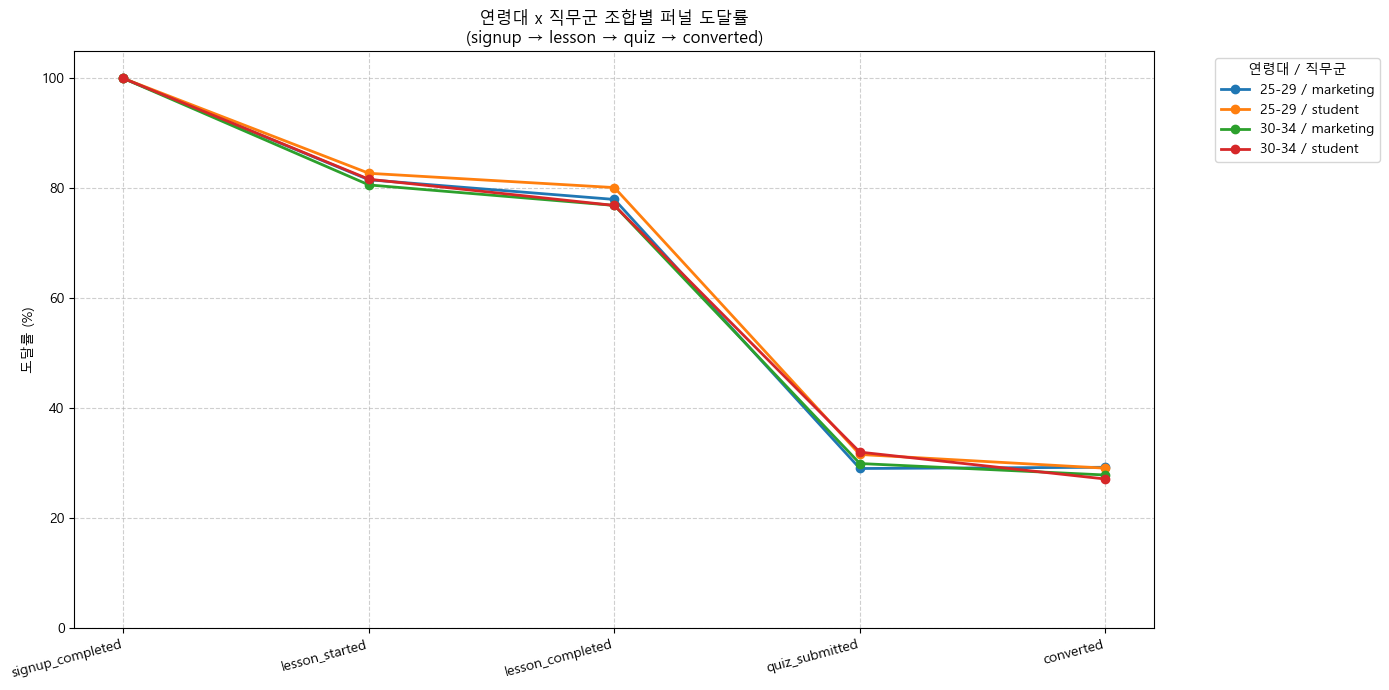

In [ ]:
# 유저 수 기준 상위 3 연령대 / 상위 3 직무군 선별 후 조합별 퍼널 도달률 분석
df_users = pd.read_csv('data/users.csv')

# 퍼널 단계 정의
funnel_steps_mixed = [
    'signup_completed',
    'lesson_started',
    'lesson_completed',
    'quiz_submitted',
    'converted'
]

# 유저별 이벤트 도달 여부 계산
user_base_funnel = df_merged.groupby('user_id')['event_name'].apply(set).reset_index()
user_base_funnel.columns = ['user_id', 'event_set']

for step in funnel_steps_mixed[:-1]:  # converted 제외
    user_base_funnel[step] = user_base_funnel['event_set'].apply(lambda x: int(step in x))

# converted 추가
user_base_funnel = pd.merge(
    user_base_funnel[['user_id'] + funnel_steps_mixed[:-1]],
    user_behavior[['user_id', 'converted']],
    on='user_id', how='left'
)
user_base_funnel['converted'] = user_base_funnel['converted'].fillna(False).astype(int)

# 세그먼트 정보 병합
user_base_funnel = pd.merge(
    user_base_funnel,
    df_users[['user_id', 'age_group', 'job_category']],
    on='user_id', how='left'
)

# 상위 3 연령대 / 직무군 선별
top3_age = user_base_funnel['age_group'].value_counts().head(2).index.tolist()
top3_job = user_base_funnel['job_category'].value_counts().head(2).index.tolist()

print('상위 3 연령대:', top3_age)
print('상위 3 직무군:', top3_job)

# 필터링 및 조합 컬럼 생성
df_filtered = user_base_funnel[
    user_base_funnel['age_group'].isin(top3_age) &
    user_base_funnel['job_category'].isin(top3_job)
].copy()
df_filtered['segment'] = df_filtered['age_group'].astype(str) + ' / ' + df_filtered['job_category'].astype(str)

print(f'\n필터링 후 유저 수: {len(df_filtered):,}명')
print('조합별 유저 수:')
display(df_filtered['segment'].value_counts().rename('유저 수').to_frame())

# 조합별 퍼널 도달률 계산
reach_by_seg = df_filtered.groupby('segment')[funnel_steps_mixed].mean() * 100
print('\n--- 연령대 x 직무군 조합별 퍼널 도달률 (%) ---')
display(reach_by_seg.round(2))

# 시각화
plt.figure(figsize=(14, 7))
for seg_val in reach_by_seg.index:
    plt.plot(
        range(len(funnel_steps_mixed)),
        reach_by_seg.loc[seg_val],
        marker='o', linewidth=2, label=str(seg_val)
    )

plt.title('연령대 x 직무군 조합별 퍼널 도달률\n(signup → lesson → quiz → converted)')
plt.ylabel('도달률 (%)')
plt.xticks(range(len(funnel_steps_mixed)), funnel_steps_mixed, rotation=15, ha='right')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='연령대 / 직무군', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 비전환 유저 이탈 전 마지막 3개 이벤트 분포 (순서별)

비전환 유저의 마지막 이벤트 / 뒤에서 2번째 이벤트 / 뒤에서 3번째 이벤트를 각각 분리하여 분포를 분석합니다.

### 퀴즈 응시 여부에 따른 lesson_completed 이후 행동 비교

lesson_completed 이벤트를 경험한 유저를 대상으로,
quiz_submitted를 한 유저와 하지 않은 유저의 이후 행동 패턴과 전환율을 비교합니다.

lesson_completed 경험 유저 수: 10,926명
  - 이후 quiz_submitted 한 유저: 4,201명
  - 퀴즈 미응시 유저: 6,725명

퀴즈 응시 유저 전환율: 53.99%
퀴즈 미응시 유저 전환율: 22.62%


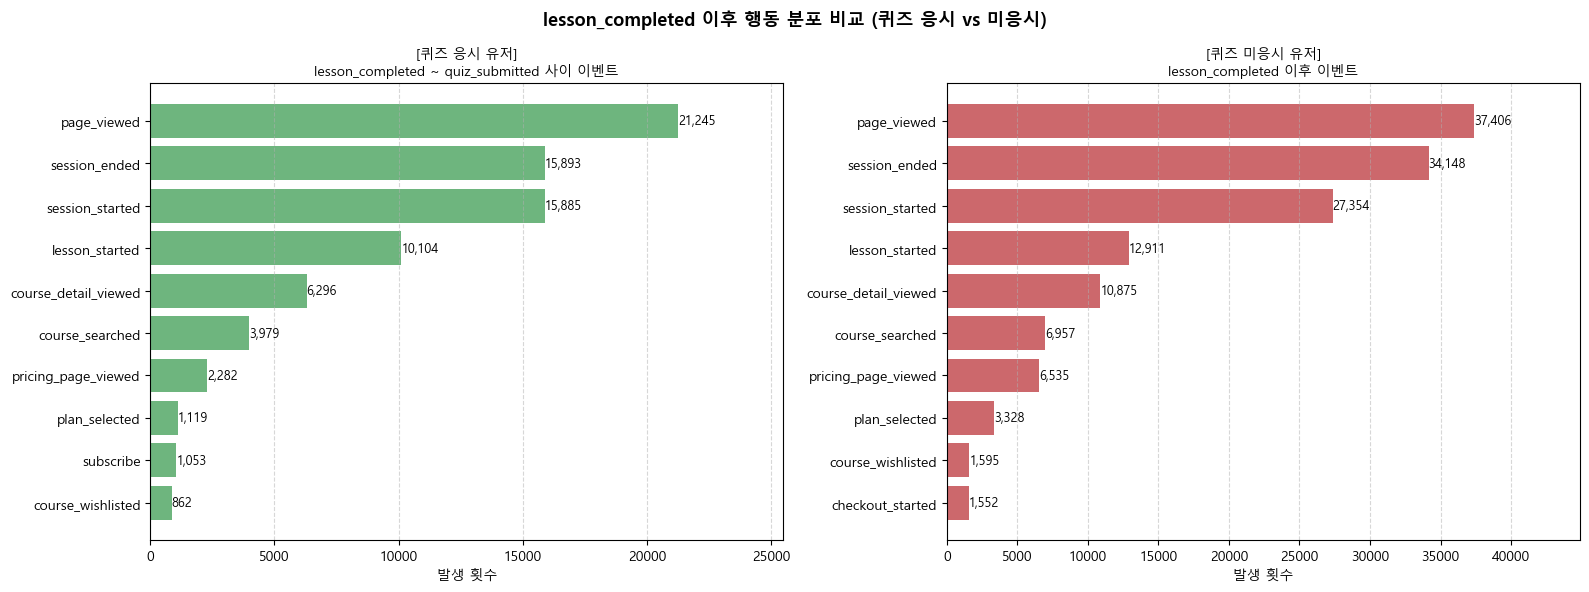

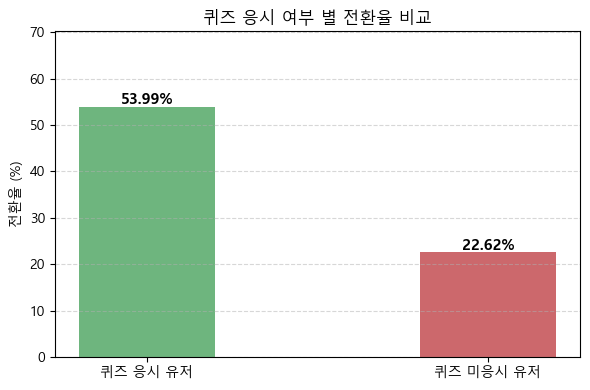

In [ ]:
# 퀴즈 응시 여부에 따른 lesson_completed 이후 행동 비교

# lesson_completed를 경험한 유저만 필터
users_lesson_done = df_merged[df_merged['event_name'] == 'lesson_completed']['user_id'].unique()
df_lesson_users = df_merged[df_merged['user_id'].isin(users_lesson_done)].copy()
df_lesson_users = df_lesson_users.sort_values(['user_id', 'event_timestamp'])

# 유저별 lesson_completed 이후 이벤트만 필터링
def get_events_after_lesson(group):
    lesson_times = group[group['event_name'] == 'lesson_completed']['event_timestamp']
    if lesson_times.empty:
        return pd.DataFrame()
    first_lesson_time = lesson_times.iloc[0]
    return group[group['event_timestamp'] >= first_lesson_time]

df_after_lesson = df_lesson_users.groupby('user_id', group_keys=False).apply(get_events_after_lesson)

# 퀴즈 응시 여부 구분
quiz_users = set(df_after_lesson[df_after_lesson['event_name'] == 'quiz_submitted']['user_id'].unique())
all_lesson_users = set(users_lesson_done)
no_quiz_users = all_lesson_users - quiz_users

print(f'lesson_completed 경험 유저 수: {len(all_lesson_users):,}명')
print(f'  - 이후 quiz_submitted 한 유저: {len(quiz_users):,}명')
print(f'  - 퀴즈 미응시 유저: {len(no_quiz_users):,}명')

# 전환율 비교
conv_quiz = user_behavior[user_behavior['user_id'].isin(quiz_users)]['converted'].mean() * 100
conv_no_quiz = user_behavior[user_behavior['user_id'].isin(no_quiz_users)]['converted'].mean() * 100
print(f'\n퀴즈 응시 유저 전환율: {conv_quiz:.2f}%')
print(f'퀴즈 미응시 유저 전환율: {conv_no_quiz:.2f}%')

# ------ 퀴즈 응시 유저: lesson_completed ~ quiz_submitted 사이 이벤트 분포 ------
def get_events_between_lesson_and_quiz(group):
    lesson_times = group[group['event_name'] == 'lesson_completed']['event_timestamp']
    quiz_times = group[group['event_name'] == 'quiz_submitted']['event_timestamp']
    if lesson_times.empty or quiz_times.empty:
        return pd.DataFrame()
    t_start = lesson_times.iloc[0]
    t_end = quiz_times.iloc[0]
    between = group[(group['event_timestamp'] >= t_start) & (group['event_timestamp'] <= t_end)]
    return between[~between['event_name'].isin(['lesson_completed', 'quiz_submitted'])]

df_quiz_users_full = df_lesson_users[df_lesson_users['user_id'].isin(quiz_users)]
df_between = df_quiz_users_full.groupby('user_id', group_keys=False).apply(get_events_between_lesson_and_quiz)

# 퀴즈 미응시 유저: lesson_completed 이후 이벤트 분포
df_no_quiz_after = df_after_lesson[
    (df_after_lesson['user_id'].isin(no_quiz_users)) &
    (~df_after_lesson['event_name'].isin(['lesson_completed']))
]

# 분포 시각화
top_n = 10
between_counts = df_between['event_name'].value_counts().head(top_n)
no_quiz_counts = df_no_quiz_after['event_name'].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('lesson_completed 이후 행동 분포 비교 (퀴즈 응시 vs 미응시)', fontsize=13, fontweight='bold')

# 퀴즈 응시 유저: 중간 이벤트
axes[0].barh(between_counts.index[::-1], between_counts.values[::-1], color='#55A868', alpha=0.85)
for i, (idx, val) in enumerate(zip(between_counts.index[::-1], between_counts.values[::-1])):
    axes[0].text(val + 3, i, f'{int(val):,}', va='center', fontsize=9)
axes[0].set_title('[퀴즈 응시 유저]\nlesson_completed ~ quiz_submitted 사이 이벤트', fontsize=10)
axes[0].set_xlabel('발생 횟수')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].set_xlim(0, between_counts.max() * 1.2 if not between_counts.empty else 10)

# 퀴즈 미응시 유저: lesson_completed 이후 이벤트
axes[1].barh(no_quiz_counts.index[::-1], no_quiz_counts.values[::-1], color='#C44E52', alpha=0.85)
for i, (idx, val) in enumerate(zip(no_quiz_counts.index[::-1], no_quiz_counts.values[::-1])):
    axes[1].text(val + 3, i, f'{int(val):,}', va='center', fontsize=9)
axes[1].set_title('[퀴즈 미응시 유저]\nlesson_completed 이후 이벤트', fontsize=10)
axes[1].set_xlabel('발생 횟수')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, no_quiz_counts.max() * 1.2 if not no_quiz_counts.empty else 10)

plt.tight_layout()
plt.show()

# 전환율 비교 시각화
fig2, ax2 = plt.subplots(figsize=(6, 4))
labels = ['퀴즈 응시 유저', '퀴즈 미응시 유저']
rates = [conv_quiz, conv_no_quiz]
colors = ['#55A868', '#C44E52']
bars2 = ax2.bar(labels, rates, color=colors, alpha=0.85, width=0.4)
for bar, rate in zip(bars2, rates):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('퀴즈 응시 여부 별 전환율 비교')
ax2.set_ylabel('전환율 (%)')
ax2.set_ylim(0, max(rates) * 1.3)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### lesson_completed ~ quiz_submitted 사이 이벤트 수 및 시간 분포

퀴즈를 응시한 유저 대상으로, lesson_completed 이후 quiz_submitted까지
몇 개의 이벤트가 발생했는지, 얼마나 걸렸는지 분포와 평균을 분석합니다.

분석 대상 유저 수: 4,201명

--- 이벤트 개수 통계 ---


,count,mean,std,min,25%,50%,75%,max
이벤트 개수,4201.0,21.5,31.81,0.0,0.0,8.0,29.0,266.0



--- 경과 시간(분) 통계 ---


,count,mean,std,min,25%,50%,75%,max
경과 시간(분),4201.0,18703.17,31268.95,0.17,2.1,3092.72,24575.75,198388.97


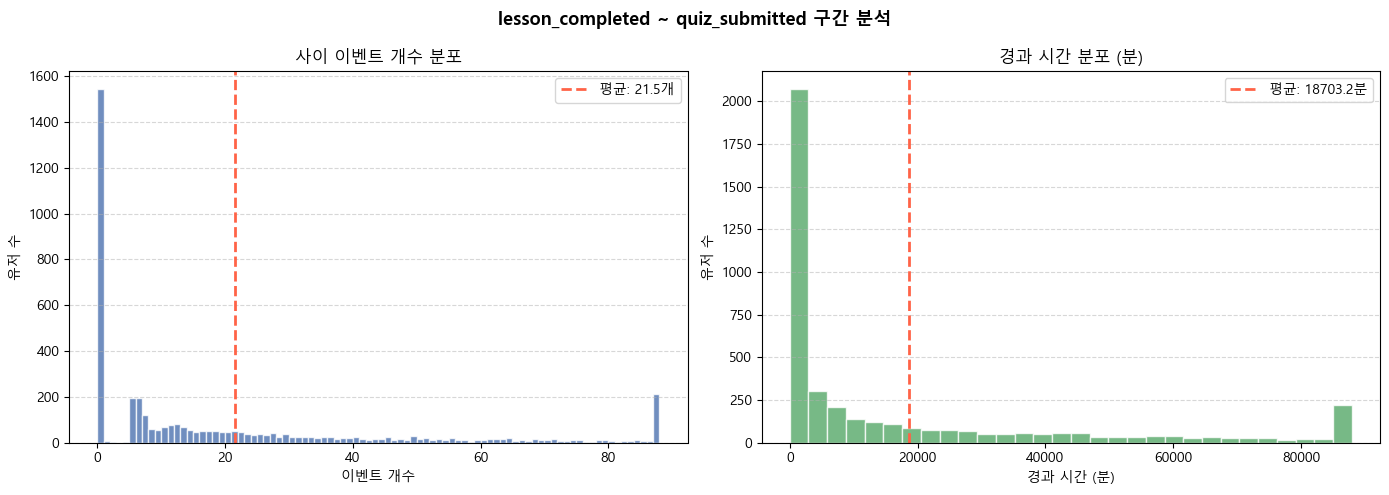

In [ ]:
# lesson_completed ~ quiz_submitted 사이 이벤트 개수 및 시간 차이 분석

# 퀴즈 응시 유저 필터
users_lesson_done_q = df_merged[df_merged['event_name'] == 'lesson_completed']['user_id'].unique()
df_quiz_base = df_merged[
    df_merged['user_id'].isin(users_lesson_done_q)
].copy().sort_values(['user_id', 'event_timestamp'])

quiz_users_q = set(df_quiz_base[df_quiz_base['event_name'] == 'quiz_submitted']['user_id'].unique())
df_quiz_only = df_quiz_base[df_quiz_base['user_id'].isin(quiz_users_q)]

# 유저별 첫 lesson_completed ~ 첫 quiz_submitted 사이 구간 계산
records = []
for uid, group in df_quiz_only.groupby('user_id'):
    lesson_times = group[group['event_name'] == 'lesson_completed']['event_timestamp']
    quiz_times = group[group['event_name'] == 'quiz_submitted']['event_timestamp']
    if lesson_times.empty or quiz_times.empty:
        continue
    t_lesson = lesson_times.iloc[0]
    t_quiz = quiz_times.iloc[0]
    if t_quiz < t_lesson:
        continue  # quiz가 lesson 이전인 예외 제거
    # 구간 사이 이벤트 (lesson_completed, quiz_submitted 자체 제외)
    between = group[
        (group['event_timestamp'] > t_lesson) &
        (group['event_timestamp'] < t_quiz)
    ]
    n_events = len(between)
    elapsed_min = (t_quiz - t_lesson).total_seconds() / 60
    records.append({'user_id': uid, 'n_events_between': n_events, 'elapsed_min': elapsed_min})

df_gap = pd.DataFrame(records)

print(f'분석 대상 유저 수: {len(df_gap):,}명')
print()
print('--- 이벤트 개수 통계 ---')
display(df_gap['n_events_between'].describe().round(2).to_frame('이벤트 개수').T)
print()
print('--- 경과 시간(분) 통계 ---')
display(df_gap['elapsed_min'].describe().round(2).to_frame('경과 시간(분)').T)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('lesson_completed ~ quiz_submitted 구간 분석', fontsize=13, fontweight='bold')

# 이벤트 개수 분포
max_events = int(df_gap['n_events_between'].quantile(0.95))
axes[0].hist(
    df_gap['n_events_between'].clip(upper=max_events),
    bins=range(0, max_events + 2), color='#4C72B0', alpha=0.8, edgecolor='white'
)
avg_events = df_gap['n_events_between'].mean()
axes[0].axvline(avg_events, color='tomato', linestyle='--', linewidth=2, label=f'평균: {avg_events:.1f}개')
axes[0].set_title('사이 이벤트 개수 분포')
axes[0].set_xlabel('이벤트 개수')
axes[0].set_ylabel('유저 수')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 경과 시간 분포
max_min = df_gap['elapsed_min'].quantile(0.95)
axes[1].hist(
    df_gap['elapsed_min'].clip(upper=max_min),
    bins=30, color='#55A868', alpha=0.8, edgecolor='white'
)
avg_min = df_gap['elapsed_min'].mean()
axes[1].axvline(avg_min, color='tomato', linestyle='--', linewidth=2, label=f'평균: {avg_min:.1f}분')
axes[1].set_title('경과 시간 분포 (분)')
axes[1].set_xlabel('경과 시간 (분)')
axes[1].set_ylabel('유저 수')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Task 5. 제안

In [80]:
import pandas as pd

# 1. 결제 데이터 전처리 (성공한 결제만 합산)
success_payments = df_payment[df_payment['status'] == 'completed'].copy()

# 유저별 총 결제 금액 계산 (한 유저가 여러 번 결제했을 가능성 대비)
user_revenue = success_payments.groupby('user_id')['amount'].sum().reset_index()

# 2. 행동 데이터와 결제 금액 데이터 병합
# user_action_funnel에 'amount' 컬럼이 붙게 됩니다.
df_final_analysis = pd.merge(
    user_action_funnel, 
    user_revenue, 
    on='user_id', 
    how='left'
).fillna({'amount': 0})

# 3. ARPPU 계산 (실제 결제한 유저 대상)
paying_users_df = df_final_analysis[df_final_analysis['converted'] == 1]
total_revenue = paying_users_df['amount'].sum()
paying_user_count = paying_users_df['user_id'].nunique()

real_arppu = total_revenue / paying_user_count if paying_user_count > 0 else 0

print(f"--- [결제 지표 산출] ---")
print(f"총 매출액: ₩{total_revenue:,.0f}")
print(f"유료 결제 유저 수: {paying_user_count:,}명")
print(f"계산된 ARPPU: ₩{real_arppu:,.0f}")

--- [결제 지표 산출] ---
총 매출액: ₩231,316,500
유료 결제 유저 수: 3,920명
계산된 ARPPU: ₩59,009


In [97]:
import pandas as pd
from datetime import datetime

# 0. 데이터 관측 종료 시점 설정
observation_end = pd.to_datetime('2025-05-31')

# 1. 결제 데이터 전처리 및 기간별 매출 할당 (Accrual 로직)
success_payments = df_payment[df_payment['status'] == 'completed'].copy()
success_payments['transaction_date'] = pd.to_datetime(success_payments['transaction_date'])

def calculate_accrued_revenue(row):
    if row['plan_name'] == 'annual_basic':
        # 결제월부터 5월 말까지의 월 수 계산 (최소 1개월 인정)
        months_active = (observation_end.month - row['transaction_date'].month) + 1
        # 연간 결제이므로 최대 12개월까지만 인정
        months_active = min(max(months_active, 1), 12)
        return (row['amount'] / 12) * months_active
    else:
        # 월간 결제는 해당 월 매출로 전액 인정 (이미 한 달치이므로)
        return row['amount']

success_payments['accrued_amount'] = success_payments.apply(calculate_accrued_revenue, axis=1)

# 2. 유저별 누적 인정 금액 합산
user_revenue = success_payments.groupby('user_id')['accrued_amount'].sum().reset_index()

# 3. 행동 데이터와 병합
df_final_analysis = pd.merge(
    user_action_funnel, 
    user_revenue, 
    on='user_id', 
    how='left'
).fillna({'accrued_amount': 0})

# 4. 수정된 ARPPU 계산 (관측 기간 내 기여도 기준)
paying_users_df = df_final_analysis[df_final_analysis['converted'] == 1]
total_accrued_revenue = paying_users_df['accrued_amount'].sum()
paying_user_count = paying_users_df['user_id'].nunique()

real_accrued_arppu = total_accrued_revenue / paying_user_count if paying_user_count > 0 else 0

print(f"--- [관측 기간 반영 결제 지표] ---")
print(f"기간 내 인정 총 매출: ₩{total_accrued_revenue:,.0f}")
print(f"유료 결제 유저 수: {paying_user_count:,}명")
print(f"수정된 ARPPU (인당 기간 기여액): ₩{real_accrued_arppu:,.0f}")

--- [관측 기간 반영 결제 지표] ---
기간 내 인정 총 매출: ₩178,681,500
유료 결제 유저 수: 3,920명
수정된 ARPPU (인당 기간 기여액): ₩45,582


In [100]:
# 1. Aha Moment 도달 여부 정의
# 분석 결과에 따라 'lesson_completed'와 'quiz_submitted'를 모두 달성한 유저를 Aha 도달로 간주
user_action_funnel['aha_reached'] = (
    (user_action_funnel['lesson_completed'] == 1) & 
    (user_action_funnel['quiz_submitted'] == 1)
).astype(int)

# 2. 지표 계산 함수
def calculate_aha_impact(df, arppu=50000):
    total_users = len(df)
    aha_users_df = df[df['aha_reached'] == 1]
    non_aha_users_df = df[df['aha_reached'] == 0]
    
    # Aha 도달률
    aha_rate = df['aha_reached'].mean()
    
    # 그룹별 전환율(CVR)
    cvr_aha = aha_users_df['converted'].mean()
    cvr_non_aha = non_aha_users_df['converted'].mean()
    
    # 현재 MRR (결제 유저 수 * 인당 평균 결제액)
    current_mrr = total_users*aha_rate*cvr_aha * arppu
    
    print(f"--- [현황 분석 결과] ---")
    print(f"1. 전체 유저 수: {total_users:,}명")
    print(f"2. Aha 도달률 (퀴즈 제출): {aha_rate:.2%}")
    print(f"3. Aha 도달 유저 전환율: {cvr_aha:.2%}")
    print(f"4. Aha 미도달 유저 전환율: {cvr_non_aha:.2%}")
    print(f"   -> Aha 도달 시 전환율이 {cvr_aha/cvr_non_aha:.1f}배 높음")
    print(f"5. 현재 예상 MRR: ₩{current_mrr:,.0f}")
    
    return aha_rate, cvr_aha, cvr_non_aha, current_mrr

# 실행
aha_rate, cvr_aha, cvr_non_aha, current_mrr = calculate_aha_impact(user_action_funnel,real_accrued_arppu)

--- [현황 분석 결과] ---
1. 전체 유저 수: 14,050명
2. Aha 도달률 (퀴즈 제출): 29.90%
3. Aha 도달 유저 전환율: 53.99%
4. Aha 미도달 유저 전환율: 16.77%
   -> Aha 도달 시 전환율이 3.2배 높음
5. 현재 예상 MRR: ₩103,380,011


In [ ]:
# 1. 현재 현황 파악
df_final_analysis['aha_reached'] = (
    (df_final_analysis['lesson_completed'] == 1) & 
    (df_final_analysis['quiz_submitted'] == 1)
).astype(int)

current_aha_rate = df_final_analysis['aha_reached'].mean()
cvr_aha = df_final_analysis[df_final_analysis['aha_reached'] == 1]['converted'].mean()
cvr_non_aha = df_final_analysis[df_final_analysis['aha_reached'] == 0]['converted'].mean()

# 2. 시뮬레이션 (Aha 도달률 10%p 상승 가정)
lift = 0.10
new_aha_rate = current_aha_rate + lift
total_users = len(df_final_analysis)

# 예상 전환 유저 수
expected_conv_count = (total_users * new_aha_rate * cvr_aha) + \
                      (total_users * (1 - new_aha_rate) * cvr_non_aha)

# 예상 기간 매출 및 증분
expected_total_revenue = expected_conv_count * real_accrued_arppu
revenue_impact = expected_total_revenue - total_accrued_revenue

print(f"\n--- [Task 5 개선안 기대 효과] ---")
print(f"현재 Aha 도달률: {current_aha_rate:.2%}")
print(f"개선 후 예상 Aha 도달률: {new_aha_rate:.2%}")
print(f"전환율 차이: Aha 도달 시 전환율이 {cvr_aha/cvr_non_aha:.1f}배 높음")
print(f"예상 매출 증대액(데이터 기간 기준): ₩{revenue_impact:,.0f}")